The usual preliminaries....


In [1]:
pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install datasets

Note: you may need to restart the kernel to use updated packages.


In [3]:
from datasets import load_dataset

imdb_dataset = load_dataset("imdb")['train']

In [4]:
train_data = []
train_data_labels = []
for item in imdb_dataset:
  train_data.append(item['text'])
  train_data_labels.append(item['label'])

In [5]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(analyzer='word',max_features=1000,lowercase=True,stop_words='english',ngram_range=(1,2))
features = vectorizer.fit_transform(train_data).toarray()

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(features,train_data_labels,train_size=0.9,random_state=123)

We will use three Decision Tree models, each one using a different splitting criterion.

In [7]:

from sklearn.tree import DecisionTreeClassifier
model_dt1 = DecisionTreeClassifier(criterion='log_loss')
model_dt2 = DecisionTreeClassifier(criterion='gini')
model_dt3 = DecisionTreeClassifier(criterion='entropy')


Train the models.

In [8]:
model_dt1 = model_dt1.fit(X=X_train,y=y_train)
model_dt2 = model_dt2.fit(X=X_train,y=y_train)
model_dt3 = model_dt3.fit(X=X_train,y=y_train)

Test the models on the validation set.

In [9]:
y_pred_dt1 = model_dt1.predict(X_val)
y_pred_dt2 = model_dt2.predict(X_val)
y_pred_dt3 = model_dt3.predict(X_val)

Now let's calculate the accuracy of the models' predictions on the validation set.

In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix
print("Decision Tree 1", accuracy_score(y_val,y_pred_dt1))
print(confusion_matrix(y_val,y_pred_dt1))
print()
print("Decision Tree 2", accuracy_score(y_val,y_pred_dt2))
print(confusion_matrix(y_val,y_pred_dt2))
print()
print("Decision Tree 3", accuracy_score(y_val,y_pred_dt3))
print(confusion_matrix(y_val,y_pred_dt3))
print()

Decision Tree 1 0.6952
[[873 368]
 [394 865]]

Decision Tree 2 0.7056
[[879 362]
 [374 885]]

Decision Tree 3 0.6948
[[879 362]
 [401 858]]



Now create the voting ensemble...

# Voting Ensemble

**We will use Majority Voting:**

This means that if model1 and model2 predict positive and model3 predicts negative, we choose positive as the correct option. We are using a majority voting method due to the example shown in the A3 document.

**Example from A3 document:**

"consider checking the three weather apps on your phone to decide whether to meet someone outdoors or indoors. If only one of the apps predicts rain, then you are more likely to take a chance on an outdoor meet-up than if two of the apps predict rain."

**How the Voting Ensemble works**
- First create a vertical stack of the 3 predictions for a review in our validation set
- Then we go through each row which contains 3 predictions for a review (from the 3 models)
- We choose the result/class/label which is most frequent (appears at least twice)
- This label is then what we choose for our voting ensemble prediction

In [35]:
import numpy as np

# vertically stack all 3 model predictions for validation set in a numpy stack
# transpose: each row corresponds to predictions of a sample from all 3 models
pred = np.vstack((y_pred_dt1, y_pred_dt2, y_pred_dt3)).T

# predict using majority voting:
# 1) each row (row = i) counts how many times a label occurs
# 2) after this, then find the label that occurs the most
# Done using --> np.bincount(row).argmax()
y_pred_ve = np.array([np.bincount(i).argmax() for i in pred])

print(f"Acccuracy of Voting Ensemble: {accuracy_score(y_val, y_pred_ve)}")
print(f"Confusion Matrix: {confusion_matrix(y_val, y_pred_ve)}")

Acccuracy of Voting Ensemble: 0.7048
Confusion Matrix: [[879 362]
 [376 883]]


## Voting Ensemble Analysis

**Accuracy**\
Voting Ensemble accuracy is the higher than our 3 Decision Tree models. However the accuracy on the validation set here is not much higher compared to the rest. Accuracy of voting ensemble is 71% while others are: 70%, 69%, 69%. So not much difference between the rest

**Confusion Matrix**\
The confusion matrix of the voting ensemble is also similar to the confusion matrices of the 3 decision tree models. So the increase in accuracy is not specific to a certain type of review (positive or negative), it is just overall more accurate.

[[879 362]
 [376 883]]


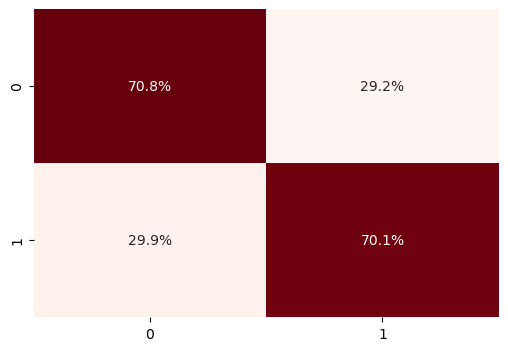

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

labels = [0, 1]

cm = confusion_matrix(y_val, y_pred_ve, labels=labels)
cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_percent = cmn * 100

# Create % signs on confusion matrix
annotations = np.asarray([['{:.1f}%'.format(value) for value in row] for row in cm_percent])

# Plot conusion matrix: with %
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm_percent, annot=annotations, fmt='', cbar=False, cmap='Reds',
            xticklabels=labels, yticklabels=labels)

print(cm)

- True Negative: 71.7% correctly predict as negative --> (890 reviews)
- False Positive: 28.3% incorrectly predict as positive --> (351 reviews)
<br>

- True Positive: 70.5% correctly predict as positive --> (887 reviews)
- False Negative: 29.5% incorrectly predict as negative --> (372 reviews)

## Use on small test set from A2
- As I had 2 test sets I will make 3 sets of predictions
- One with the **easy** data test set
- One with the **hard** data test set
- One with **both** test sets combined

### Easy Data
---
Should predict correctly | 100% accuracy

In [37]:
import pandas as pd

dune = ["Watching this in IMAX is the correct way to watch. That is what the movies were made for. Incredible",
        "This is truly the cinematic event of our generation… don’t take it for granted",
        "this is #1. my favorite movie. it led me to paradise."]

megalopoplis = ["""Doesn't know what it should be. Cool idea but it feels like the end product doesn't match the vision. 
Some of the cinematography was brilliant while some scenes completely contradict that point. 
As the film progresses the obvious green screen becomes hard to avoid, which probably comes down to budgeting issues. 
Sometimes there's several plots going on at once, with none that are really good enough to really catch you attention, 
making it difficult to understand whats actually happening. 
Positive points are that there are some really nice shots & the world seems interesting to explore and understand. 
Glad to have watched because it's definitely an experience.""",
                "WORST movie i have ever seen.", 
                "most nonsensical and absurd movie i ever saw, unpleasant and annoying"]

dune_df = pd.DataFrame({'text': dune, 'label': [1, 1, 1]}, index=[0, 1, 2])
megalopoplis_df = pd.DataFrame({'text': megalopoplis, 'label': [0, 0, 0]}, index=[3, 4, 5])

easy_data = pd.concat([dune_df, megalopoplis_df])

# Voting Ensemble
pred1 = model_dt1.predict(vectorizer.transform(easy_data["text"]).toarray())
pred2 = model_dt2.predict(vectorizer.transform(easy_data["text"]).toarray())
pred3 = model_dt2.predict(vectorizer.transform(easy_data["text"]).toarray())

pred_easy = np.vstack((pred1, pred2, pred3)).T
y_pred_ve_easy = np.array([np.bincount(i).argmax() for i in pred_easy])

### Hard Data
---
Should predict incorrectly | 0% accuracy

In [38]:
layer_cake = ["Action movie with a plot that keeps you there, confused but decent nonetheless", 
            "The budget of Layer Cake was 6.5 million. It looked like it was shot for 60 million dollars.", 
            "that yellow range rover is so ugly, yet so cool"]

jack_and_jill = ["Adam Sandler has blackmail on all of Hollywood, doesn't he", 
                 "I enjoyed none of this", 
                 "I thank my lucky stars I was unconscious for most of this"]

layer_cake_df = pd.DataFrame({'text': layer_cake, 'label': [1, 1, 1]}, index=[0, 1, 2])
jack_and_jill_df = pd.DataFrame({'text': jack_and_jill, 'label': [0, 0, 0]}, index=[3, 4, 5])

hard_data = pd.concat([layer_cake_df, jack_and_jill_df])

# Voting Ensemble
pred1 = model_dt1.predict(vectorizer.transform(hard_data["text"]).toarray())
pred2 = model_dt2.predict(vectorizer.transform(hard_data["text"]).toarray())
pred3 = model_dt2.predict(vectorizer.transform(hard_data["text"]).toarray())

pred_hard = np.vstack((pred1, pred2, pred3)).T
y_pred_ve_hard = np.array([np.bincount(i).argmax() for i in pred_hard])

### Both Data

In [39]:
both_data = pd.concat([easy_data, hard_data])

# reindex
both_data.reset_index(drop=True, inplace=True)

# Voting Ensemble
pred1 = model_dt1.predict(vectorizer.transform(both_data["text"]).toarray())
pred2 = model_dt2.predict(vectorizer.transform(both_data["text"]).toarray())
pred3 = model_dt2.predict(vectorizer.transform(both_data["text"]).toarray())

pred_both = np.vstack((pred1, pred2, pred3)).T
y_pred_ve_both = np.array([np.bincount(i).argmax() for i in pred_both])

## Accuracy & Confusion Matrices on Small Test Data

### Easy Data: Accuracy & Confusion Matrix

0.6666666666666666
[[1 2]
 [0 3]]


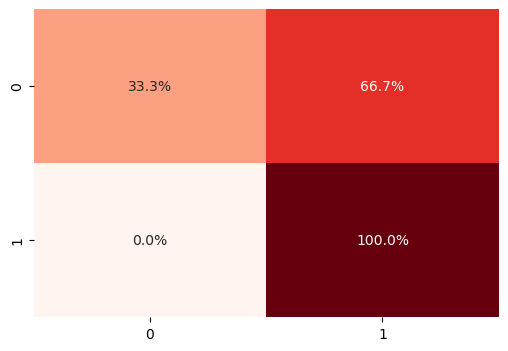

In [40]:
print(accuracy_score(easy_data["label"], y_pred_ve_easy))
labels = [0, 1]

cm = confusion_matrix(easy_data["label"], y_pred_ve_easy, labels=labels)
cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_percent = cmn * 100

# Create % signs on confusion matrix
annotations = np.asarray([['{:.1f}%'.format(value) for value in row] for row in cm_percent])

# Plot conusion matrix: with %
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm_percent, annot=annotations, fmt='', cbar=False, cmap='Reds',
            xticklabels=labels, yticklabels=labels)

print(cm)

### Confusion Matrix
- True Negative: 1/3 correctly predict as negative --> (1 review)
- False Positive: 2/3 incorrectly predict as positive --> (2 review)
<br>

- True Positive: 100% correctly predict as positive --> (3 reviews)
- False Negative: None incorrectly predict as negative

### Analyse Predictions
- The accuracy of the voting ensemble on the easy test data is 66.7%. In A2 the data was designed to have an accuracy of 100%
- i.e always predict the review correctly 
- From the confusion matrix we can see that the voting ensemble **incorectly predicted 2 negative reviews as positive**
- The voting ensemble decreased the accuracy of predcitions & did not help achieve what we wanted our data to do
- The voting ensemble struggled with predicting negative reviews correctly

## Hard Data: Accuracy & Confusion Matrix

0.3333333333333333
[[0 3]
 [1 2]]


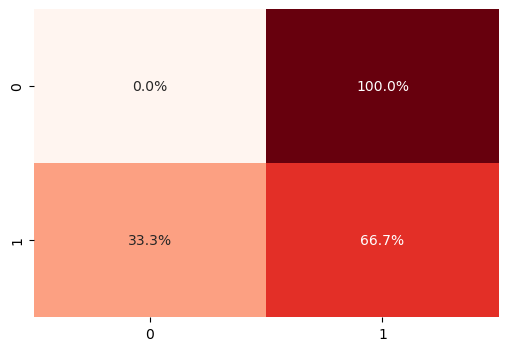

In [41]:
print(accuracy_score(hard_data["label"], y_pred_ve_hard))

cm = confusion_matrix(hard_data["label"], y_pred_ve_hard, labels=labels)
cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_percent = cmn * 100

# Create % signs on confusion matrix
annotations = np.asarray([['{:.1f}%'.format(value) for value in row] for row in cm_percent])

# Plot conusion matrix: with %
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm_percent, annot=annotations, fmt='', cbar=False, cmap='Reds',
            xticklabels=labels, yticklabels=labels)

print(cm)

### Confusion Matrix
- True Negative: None correctly predict as negative
- False Positive: 100% incorrectly predict as positive --> (3 reviews)
<br>

- True Positive: 2/3 correctly predict as positive --> (2 reviews)
- False Negative: 1/3 incorrectly predict as negative --> (1 reviews)

### Analyse Predictions
- The accuracy of the voting ensemble on the easy test data is 33.3%. In A2 the data was designed to have an accuracy of 0%
- i.e always predict the review incorrectly 
- From the confusion matrix we can see that the voting ensemble **corectly predicted 2 positive reviews as positive**
- The voting ensemble increased the accuracy of predcitions BUT did not help achieve what we wanted our data to do
- The voting ensemble "helped" (in a bad way) to predict positive reviews correctly

## Both Data: Accuracy & Confusion Matrix

0.5
[[1 5]
 [1 5]]


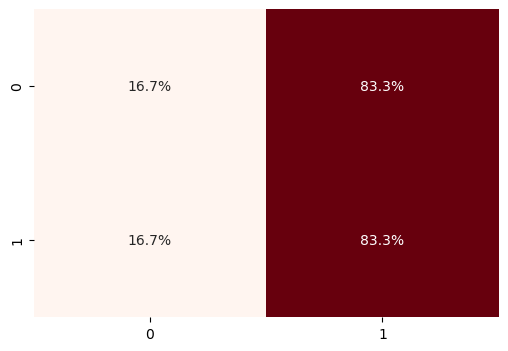

In [42]:
print(accuracy_score(both_data["label"], y_pred_ve_both))

cm = confusion_matrix(both_data["label"], y_pred_ve_both, labels=labels)
cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_percent = cmn * 100

# Create % signs on confusion matrix
annotations = np.asarray([['{:.1f}%'.format(value) for value in row] for row in cm_percent])

# Plot conusion matrix: with %
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm_percent, annot=annotations, fmt='', cbar=False, cmap='Reds',
            xticklabels=labels, yticklabels=labels)

print(cm)

- True Negative: 1/6 correctly predict as negative --> (1 review)
- False Positive: 5/6 incorrectly predict as positive --> (5 reviews)
<br>

- True Positive: 5/6 correctly predict as positive --> (5 reviews)
- False Negative: 1/6 incorrectly predict as negative --> (1 review)

### Analyse Predictions
- The accuracy of the voting ensemble on the easy test data is 50%
- From the confusion matrix we can see that the voting ensemble **incorectly predicted 5 negative reviews as positive**
- It also **incorrectly predicted 1 positive review as negative**
- The voting ensemble struggled more with predicting negative reviews correctly

## Overall conclusion on small test data
- The voting ensemble struggled in predicting negative reviews correctly, as seen in all 3 test sets
- The voting ensemble did well in predicting positive reviews correctly as seen in all 3 test sets
- The voting ensemble **helped** predictions in the hard data test set (which in A2 is not what we wanted)
- The voting ensemble **damaged** predictions in the easy data test set (which in A2 is not what we wanted)